In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shyamnadhs/heart-disease-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-prediction-dataset


In [4]:
import os

print(os.listdir("/kaggle/input/heart-disease-prediction-dataset"))

['disease_prediction.csv']


In [5]:
import os

print(os.listdir("/kaggle/input/heart-disease-prediction-dataset"))

['disease_prediction.csv']


In [6]:
import pandas as pd

df = pd.read_csv("/kaggle/input/heart-disease-prediction-dataset/disease_prediction.csv")

df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


In [8]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
glucose_mg_dl,0
cholesterol_mg_dl,0
systolic_bp,0
diastolic_bp,0
bmi,0
heart_rate,0
smoking,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop("patient_id", axis=1)

In [11]:
df.head()

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


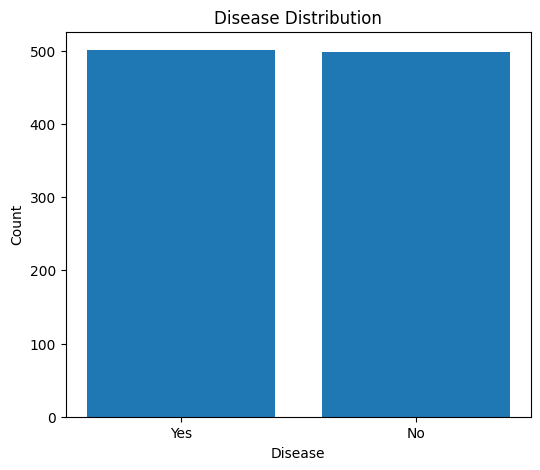

In [12]:
import matplotlib.pyplot as plt

counts = df["disease"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(counts.index, counts.values)

plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")

plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

encoder = LabelEncoder()

for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

df_encoded.head()

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,1,101,235,152,79,28.5,73,0,1,1,1,1
1,31,1,124,191,134,77,33.9,71,0,1,1,1,1
2,45,1,57,141,114,71,27.2,79,1,1,1,0,0
3,75,0,69,268,120,82,21.5,61,1,1,2,0,1
4,53,1,107,163,131,75,23.3,73,1,0,1,1,1


In [14]:
X = df_encoded.drop("disease", axis=1)
y = df_encoded["disease"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [17]:
y_pred = baseline_model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.74
Precision: 0.75
Recall: 0.72
F1 Score: 0.7346938775510204


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [21]:
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [22]:
import numpy as np

epsilon = 1e-15
y_prob = np.clip(y_prob, epsilon, 1 - epsilon)

log_loss = -np.mean(
    y_test * np.log(y_prob) + (1 - y_test) * np.log(1 - y_prob)
)

print("Log Loss:", log_loss)

Log Loss: 0.4840282640920466


In [23]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log Loss:", log_loss)

Accuracy: 0.74
Log Loss: 0.4840282640920466


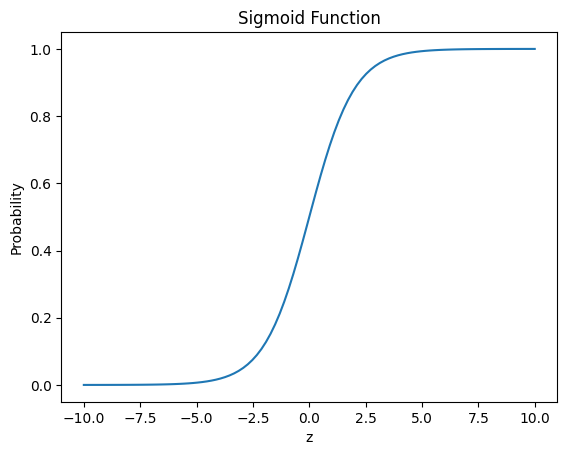

In [24]:
import matplotlib.pyplot as plt

z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.plot(z, sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("Probability")
plt.show()

In [25]:
df_fe = df_encoded.copy()

df_fe["bp_ratio"] = df_fe["systolic_bp"] / df_fe["diastolic_bp"]
df_fe["chol_glucose"] = df_fe["cholesterol_mg_dl"] * df_fe["glucose_mg_dl"]

In [26]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

In [27]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=2000,
    C=0.1,
    solver="lbfgs"
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(C=0.1, max_iter=2000)

In [28]:
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

y_pred_new = (y_prob >= 0.4).astype(int)

In [29]:
from sklearn.metrics import accuracy_score

print("New Accuracy:", accuracy_score(y_test, y_pred_new))

New Accuracy: 0.74


In [30]:
df_model = df.copy()

In [32]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [33]:
X = df_model.drop("disease_Yes", axis=1)
y = df_model["disease_Yes"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    C=1.0,
    solver="lbfgs"
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [37]:
from sklearn.metrics import accuracy_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.84
F1: 0.8446601941747572


In [38]:
y_prob = model.predict_proba(X_test)[:,1]

y_pred_new = (y_prob >= 0.45).astype(int)

print("New Accuracy:", accuracy_score(y_test, y_pred_new))

New Accuracy: 0.825


In [39]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=8)

X_new = selector.fit_transform(X, y)

In [40]:
model = LogisticRegression(C=0.1, max_iter=3000)

In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores.mean())

0.842


In [42]:
import numpy as np

X = df_model.drop("disease_Yes", axis=1).values
y = df_model["disease_Yes"].values

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [44]:
X = np.c_[np.ones(X.shape[0]), X]

In [45]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [46]:
def compute_loss(y, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))

In [47]:
m, n = X.shape
weights = np.zeros(n)
lr = 0.01

loss_history = []

for i in range(2000):
    z = np.dot(X, weights)
    y_pred = sigmoid(z)

    gradient = np.dot(X.T, (y_pred - y)) / m
    weights -= lr * gradient

    loss = compute_loss(y, y_pred)
    loss_history.append(loss)

    if i % 200 == 0:
        print(f"Iteration {i}, Loss: {loss}")

Iteration 0, Loss: 0.6931471805599454
Iteration 200, Loss: 0.5342999480828262
Iteration 400, Loss: 0.4655808640090448
Iteration 600, Loss: 0.42847848123739757
Iteration 800, Loss: 0.40543625677117995
Iteration 1000, Loss: 0.389817071102994
Iteration 1200, Loss: 0.3785926945861555
Iteration 1400, Loss: 0.37018633807192763
Iteration 1600, Loss: 0.36369499218574175
Iteration 1800, Loss: 0.35856336490005025


In [48]:
y_prob = sigmoid(np.dot(X, weights))
y_pred = (y_prob >= 0.5).astype(int)

In [49]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(y, y_pred))
print("F1:", f1_score(y, y_pred))

Accuracy: 0.846
F1: 0.845691382765531


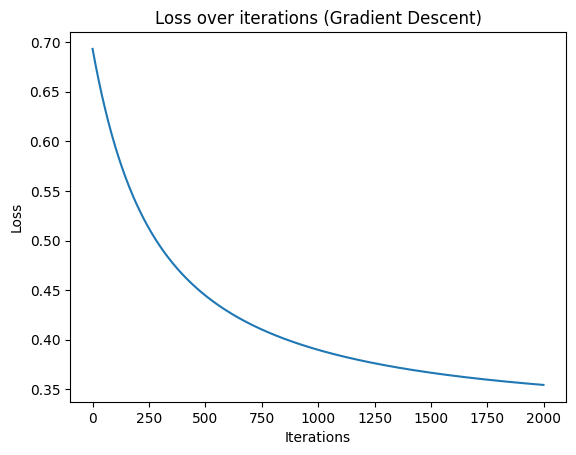

In [50]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Loss over iterations (Gradient Descent)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [55]:

y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.86      0.81      0.84       100
        True       0.82      0.87      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



In [57]:
from sklearn.model_selection import GridSearchCV

params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=3000), params, cv=5)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [58]:
best_model = grid.best_estimator_

In [59]:
y_pred = best_model.predict(X_test)

In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.86      0.81      0.84       100
        True       0.82      0.87      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



In [61]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [62]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.84
F1 Score: 0.8446601941747572

Classification Report:

              precision    recall  f1-score   support

       False       0.86      0.81      0.84       100
        True       0.82      0.87      0.84       100

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



In [63]:
from sklearn.preprocessing import KBinsDiscretizer

cols_to_bin = [
    "age",
    "glucose_mg_dl",
    "cholesterol_mg_dl",
    "bmi",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate"
]

df_bin = df.copy()

In [64]:
kbd = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='quantile'  # مهم جدًا
)

df_bin[cols_to_bin] = kbd.fit_transform(df_bin[cols_to_bin])

In [65]:
df_bin = pd.get_dummies(df_bin, drop_first=True)

X = df_bin.drop("disease_Yes", axis=1)
y = df_bin["disease_Yes"]

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.845
              precision    recall  f1-score   support

       False       0.87      0.81      0.84       100
        True       0.82      0.88      0.85       100

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



In [69]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [70]:
model = LogisticRegression(max_iter=3000)
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

In [71]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=8)

X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

In [72]:
model = LogisticRegression(C=10, max_iter=3000)

In [75]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [76]:
y_pred = model.predict(X_test)

In [77]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.845
              precision    recall  f1-score   support

       False       0.87      0.81      0.84       100
        True       0.82      0.88      0.85       100

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



In [78]:
df_fe = df_model.copy()

df_fe["bp_ratio"] = df_fe["systolic_bp"] / (df_fe["diastolic_bp"] + 1)
df_fe["chol_glucose"] = df_fe["cholesterol_mg_dl"] * df_fe["glucose_mg_dl"]
df_fe["age_bmi"] = df_fe["age"] * df_fe["bmi"]

In [79]:
from sklearn.preprocessing import StandardScaler

X = df_fe.drop("disease_Yes", axis=1)
y = df_fe["disease_Yes"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [80]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=10,              #
    penalty="l2",
    solver="lbfgs",
    max_iter=5000
)

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [82]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [83]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.845
              precision    recall  f1-score   support

       False       0.87      0.81      0.84       100
        True       0.82      0.88      0.85       100

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



In [84]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42, stratify=y
)

In [86]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=10, max_iter=5000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [87]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(k=10)

X_new = selector.fit_transform(X, y)

In [88]:
y_prob = model.predict_proba(X_test)[:,1]

y_pred_new = (y_prob >= 0.45).astype(int)

In [89]:
model = LogisticRegression(
    C=10,          # جرب 0.1 / 1 / 10 / 100
    penalty='l2',
    max_iter=5000
)

In [92]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

In [93]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [94]:
y_pred = model.predict(X_test)

In [95]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.81
              precision    recall  f1-score   support

       False       0.84      0.77      0.80       100
        True       0.79      0.85      0.82       100

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



In [96]:
cols_to_bin = [
    "age",
    "glucose_mg_dl",
    "cholesterol_mg_dl",
    "bmi",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate"
]

In [97]:
from sklearn.preprocessing import KBinsDiscretizer

kbd = KBinsDiscretizer(
    n_bins=4,
    encode='ordinal',
    strategy='quantile'   # الأفضل عادة
)

df_bin = df.copy()
df_bin[cols_to_bin] = kbd.fit_transform(df_bin[cols_to_bin])

In [98]:
df_bin = pd.get_dummies(df_bin, drop_first=True)

X = df_bin.drop("disease_Yes", axis=1)
y = df_bin["disease_Yes"]

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [100]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    C=10
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [101]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.845
              precision    recall  f1-score   support

       False       0.88      0.80      0.84       100
        True       0.82      0.89      0.85       100

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200

